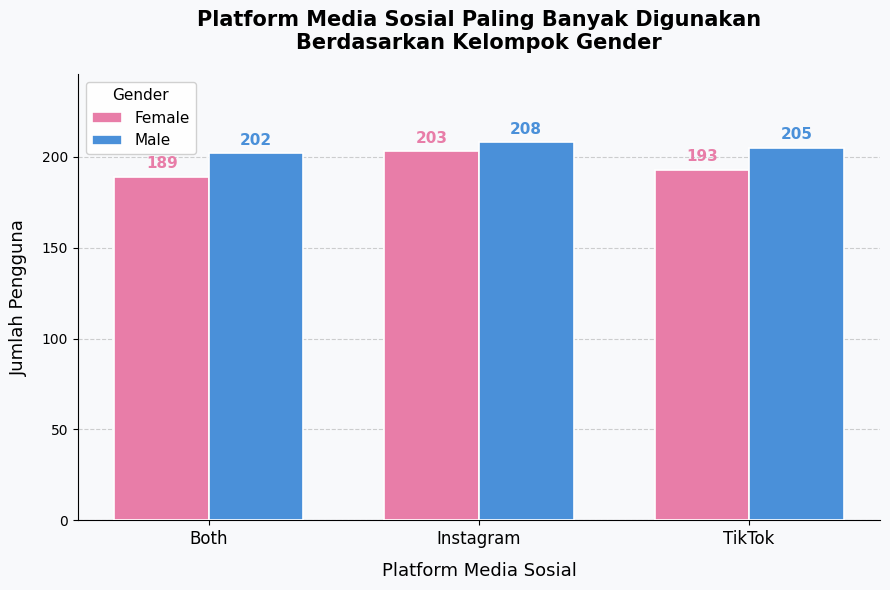

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Style Seaborn
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Salinan Kelas E_Teen Mental Health.csv")

# Menghitung jumlah pengguna berdasarkan gender dan platform
counts = df.groupby(['gender', 'platform_usage']).size().unstack(fill_value=0)

platforms = counts.columns.tolist()
x = np.arange(len(platforms))
width = 0.35

color_female = '#E87DA8'
color_male = '#4A90D9'

fig, ax = plt.subplots(figsize=(9, 6))

bars_female = ax.bar(
    x - width/2,
    counts.loc['female'],
    width,
    label='Female',
    color=color_female
)

bars_male = ax.bar(
    x + width/2,
    counts.loc['male'],
    width,
    label='Male',
    color=color_male
)

for bar in bars_female:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

for bar in bars_male:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

ax.set_xlabel('Platform Media Sosial')
ax.set_ylabel('Jumlah Pengguna')
ax.set_title(
    'Platform Media Sosial Paling Banyak Digunakan\nBerdasarkan Kelompok Gender',
    fontsize=15,
    fontweight='bold'
)

ax.set_xticks(x)
ax.set_xticklabels(platforms)

ax.legend(title='Gender')

plt.tight_layout()
plt.show()

Jumlah remaja dengan screen time > 2.5 jam: 202


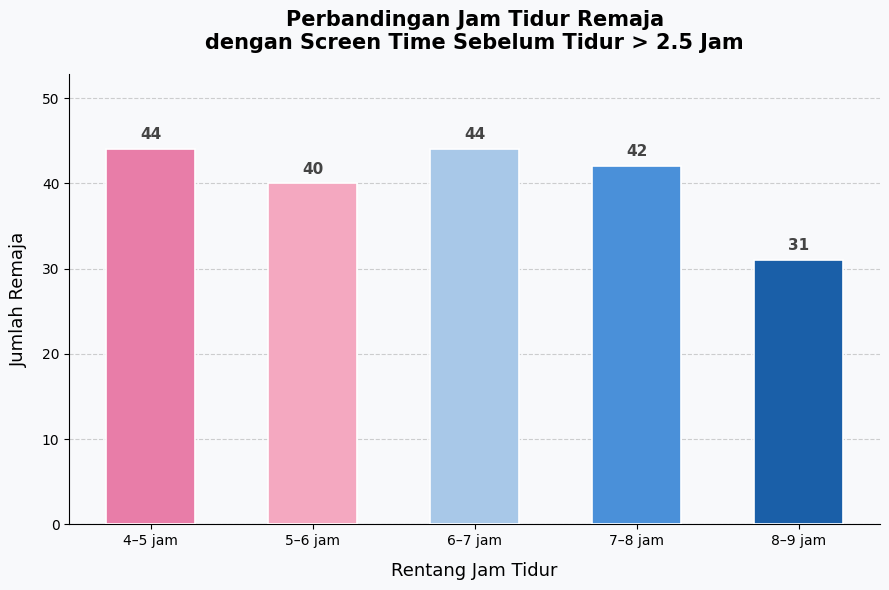

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Style Seaborn
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Salinan Kelas E_Teen Mental Health.csv")

# Filter data
filtered = df[df['screen_time_before_sleep'] > 2.5].copy()

print(f"Jumlah remaja dengan screen time > 2.5 jam: {len(filtered)}")

# Binning jam tidur
bins = [4, 5, 6, 7, 8, 9]
labels = ['4–5 jam', '5–6 jam', '6–7 jam', '7–8 jam', '8–9 jam']

filtered['sleep_category'] = pd.cut(
    filtered['sleep_hours'],
    bins=bins,
    labels=labels,
    right=True
)

sleep_counts = filtered['sleep_category'].value_counts().reindex(labels)

colors = ['#E87DA8', '#F4A8C0', '#A8C8E8', '#4A90D9', '#1A5FA8']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    labels,
    sleep_counts,
    color=colors,
    width=0.6
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

ax.set_xlabel('Rentang Jam Tidur')
ax.set_ylabel('Jumlah Remaja')

ax.set_title(
    'Perbandingan Jam Tidur Remaja\n'
    'dengan Screen Time Sebelum Tidur > 2.5 Jam',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Korelasi: -0.0250


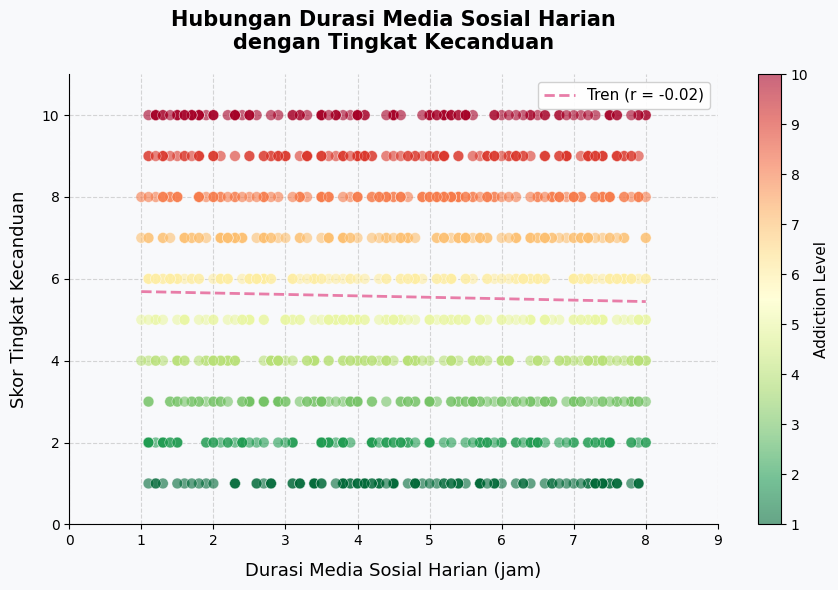

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Style Seaborn
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Salinan Kelas E_Teen Mental Health.csv")

# Variabel
x = df['daily_social_media_hours']
y = df['addiction_level']

# Regresi linear dengan NumPy
m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

# Korelasi
korelasi = x.corr(y)
print(f"Korelasi: {korelasi:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    x=x,
    y=y,
    hue=y,
    palette='RdYlGn_r',
    s=70,
    alpha=0.7,
    legend=False,
    ax=ax
)

# Garis tren
ax.plot(
    x_line,
    y_line,
    color='#E87DA8',
    linestyle='--',
    linewidth=2,
    label=f'Tren (r = {korelasi:.2f})'
)

ax.set_xlabel('Durasi Media Sosial Harian (jam)')
ax.set_ylabel('Skor Tingkat Kecanduan')

ax.set_title(
    'Hubungan Durasi Media Sosial Harian\n'
    'dengan Tingkat Kecanduan',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlim(0, 9)
ax.set_ylim(0, 11)

ax.legend()

plt.tight_layout()
plt.show()

Mean   : 5.57
Median : 6.00
Std Dev: 2.83


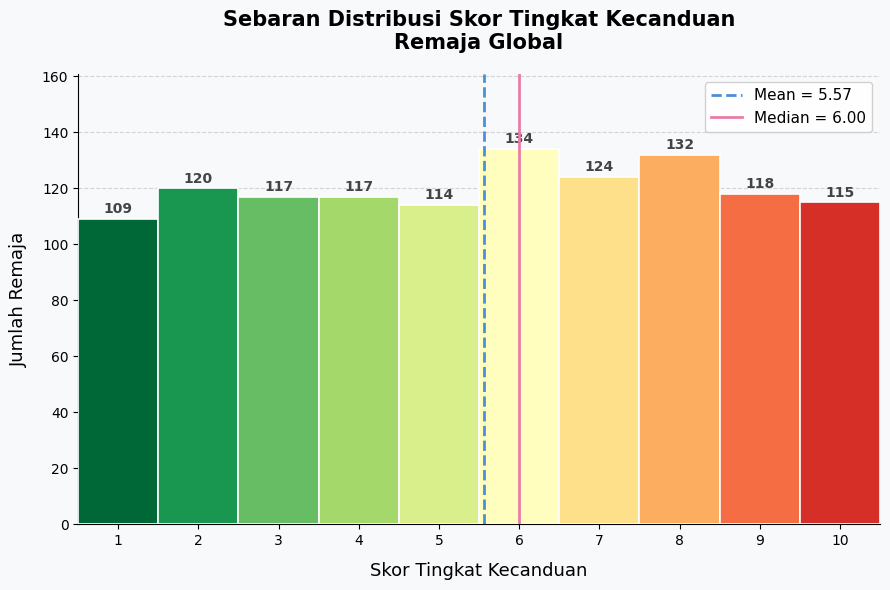

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ── Style Seaborn ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")

# ── 1. Load dataset ───────────────────────────────────────────────────────────
df = pd.read_csv("Salinan Kelas E_Teen Mental Health.csv")

# ── 2. Ambil kolom addiction_level ────────────────────────────────────────────
data = df['addiction_level']

# ── 3. Statistik deskriptif ───────────────────────────────────────────────────
mean_val = np.mean(data)
median_val = np.median(data)
std_val = np.std(data)

print(f"Mean   : {mean_val:.2f}")
print(f"Median : {median_val:.2f}")
print(f"Std Dev: {std_val:.2f}")

# ── 4. Buat Histogram dengan Seaborn ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

hist = sns.histplot(
    data=data,
    bins=10,
    kde=False,
    ax=ax
)

# ── 5. Beri warna gradasi hijau → merah ──────────────────────────────────────
cmap = plt.cm.RdYlGn_r

for i, patch in enumerate(ax.patches):
    patch.set_facecolor(cmap(i / len(ax.patches)))
    patch.set_edgecolor('white')
    patch.set_linewidth(1.2)

# ── 6. Tambahkan label jumlah di atas bar ─────────────────────────────────────
for patch in ax.patches:
    height = patch.get_height()

    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width()/2,
            height + 1,
            str(int(height)),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# ── 7. Garis Mean dan Median ──────────────────────────────────────────────────
ax.axvline(
    mean_val,
    color='#4A90D9',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_val:.2f}'
)

ax.axvline(
    median_val,
    color='#E87DA8',
    linestyle='-',
    linewidth=2,
    label=f'Median = {median_val:.2f}'
)

# ── 8. Styling ────────────────────────────────────────────────────────────────
ax.set_xlabel('Skor Tingkat Kecanduan', fontsize=13)
ax.set_ylabel('Jumlah Remaja', fontsize=13)

ax.set_title(
    'Sebaran Distribusi Skor Tingkat Kecanduan\nRemaja Global',
    fontsize=15,
    fontweight='bold'
)

ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)

ax.legend()

plt.tight_layout()
plt.show()

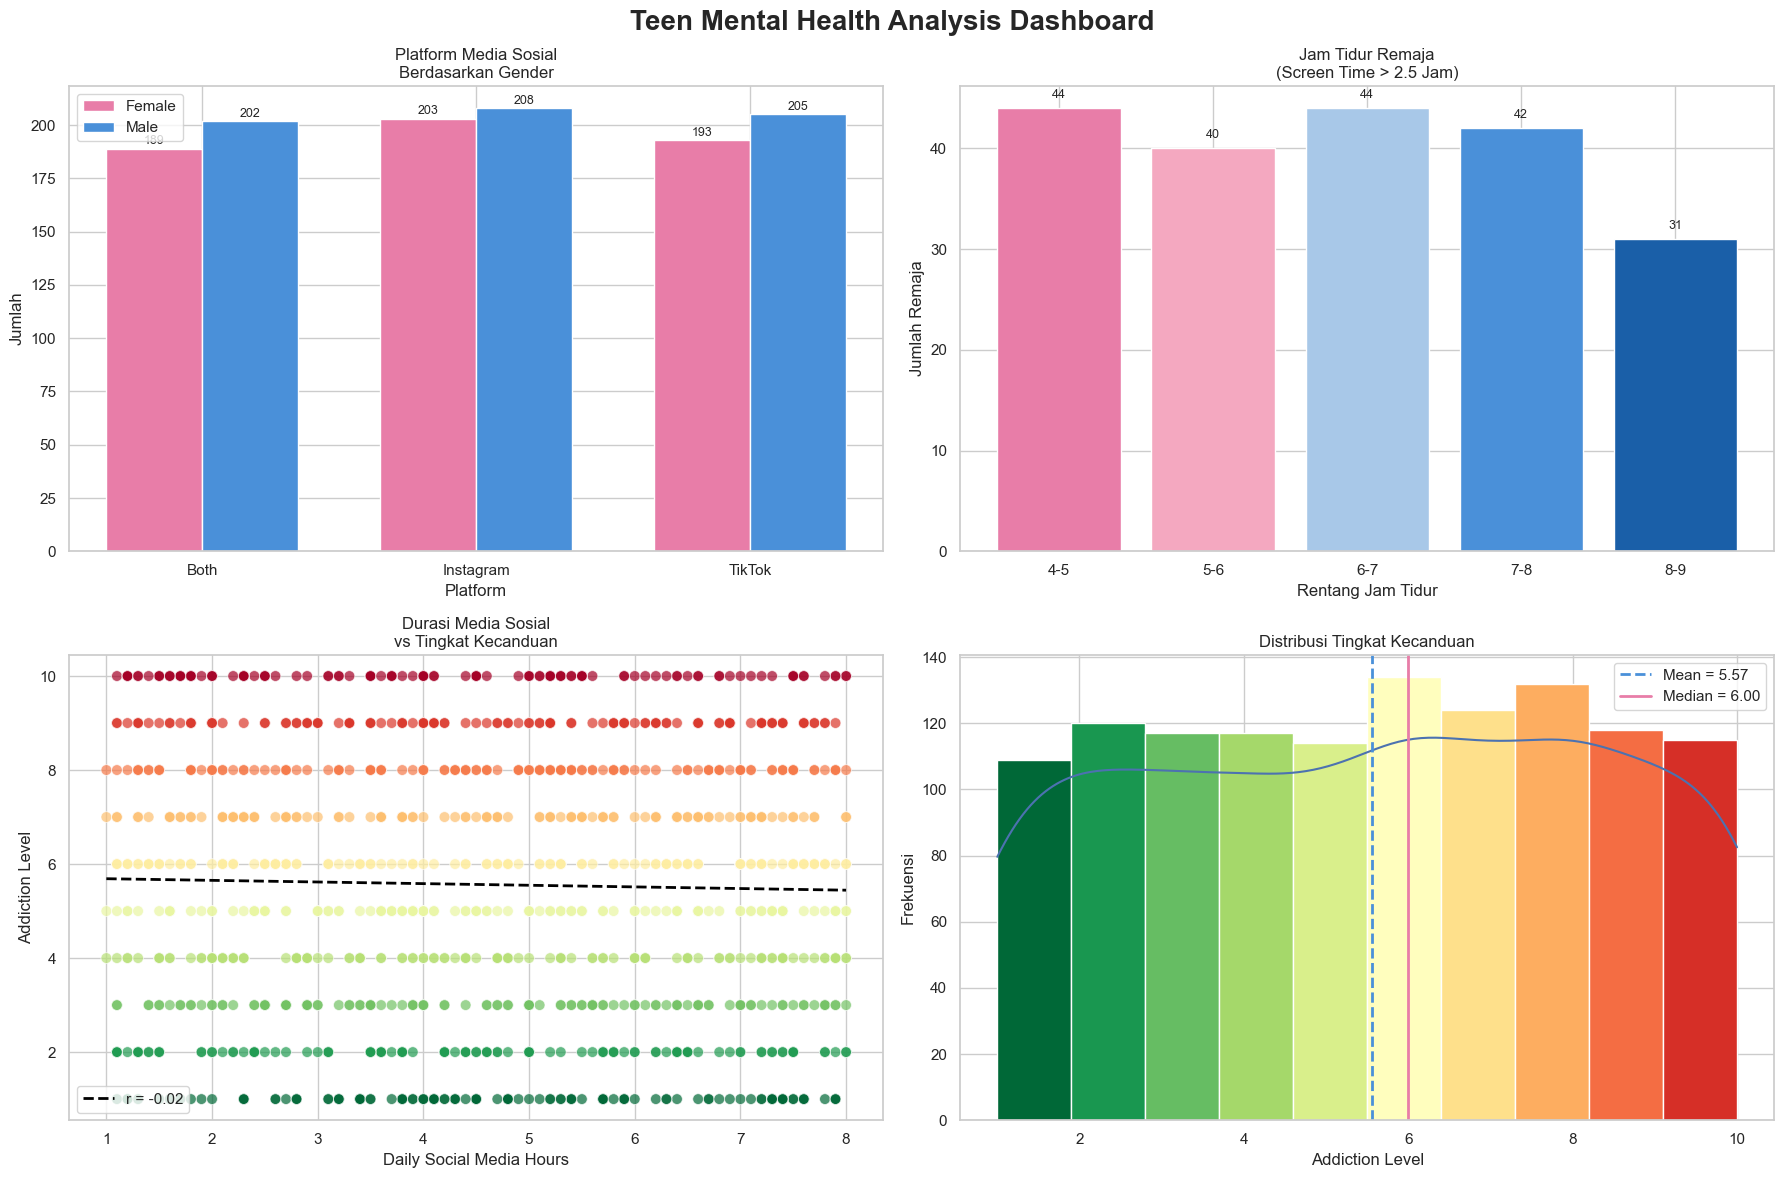


===== STATISTIK DESKRIPTIF =====
Mean Addiction Level   : 5.57
Median Addiction Level : 6.00
Std Dev Addiction Level: 2.83
Korelasi Social Media vs Addiction: -0.0250


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# =====================================================
# LOAD DATASET
# =====================================================
df = pd.read_csv("Salinan Kelas E_Teen Mental Health.csv")

# =====================================================
# STYLE
# =====================================================
sns.set_theme(style="whitegrid")

# =====================================================
# MEMBUAT CANVAS 2x2
# =====================================================
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Teen Mental Health Analysis Dashboard",
    fontsize=20,
    fontweight='bold'
)

# =====================================================
# GRAFIK 1
# Platform Media Sosial Berdasarkan Gender
# =====================================================
counts = df.groupby(
    ['gender', 'platform_usage']
).size().unstack(fill_value=0)

platforms = counts.columns.tolist()

x = np.arange(len(platforms))
width = 0.35

bars_female = axs[0,0].bar(
    x - width/2,
    counts.loc['female'],
    width,
    color='#E87DA8',
    label='Female'
)

bars_male = axs[0,0].bar(
    x + width/2,
    counts.loc['male'],
    width,
    color='#4A90D9',
    label='Male'
)

for bar in list(bars_female) + list(bars_male):
    axs[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9
    )

axs[0,0].set_title(
    'Platform Media Sosial\nBerdasarkan Gender'
)
axs[0,0].set_xlabel('Platform')
axs[0,0].set_ylabel('Jumlah')
axs[0,0].set_xticks(x)
axs[0,0].set_xticklabels(platforms)
axs[0,0].legend()

# =====================================================
# GRAFIK 2
# Screen Time > 2.5 Jam vs Jam Tidur
# =====================================================
filtered = df[
    df['screen_time_before_sleep'] > 2.5
].copy()

bins = [4, 5, 6, 7, 8, 9]
labels = ['4-5', '5-6', '6-7', '7-8', '8-9']

filtered['sleep_category'] = pd.cut(
    filtered['sleep_hours'],
    bins=bins,
    labels=labels,
    right=True
)

sleep_counts = (
    filtered['sleep_category']
    .value_counts()
    .reindex(labels)
)

colors = [
    '#E87DA8',
    '#F4A8C0',
    '#A8C8E8',
    '#4A90D9',
    '#1A5FA8'
]

bars = axs[0,1].bar(
    labels,
    sleep_counts,
    color=colors
)

for bar in bars:
    axs[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9
    )

axs[0,1].set_title(
    'Jam Tidur Remaja\n(Screen Time > 2.5 Jam)'
)
axs[0,1].set_xlabel('Rentang Jam Tidur')
axs[0,1].set_ylabel('Jumlah Remaja')

# =====================================================
# GRAFIK 3
# Social Media Hours vs Addiction Level
# =====================================================
x_data = df['daily_social_media_hours']
y_data = df['addiction_level']

m, b = np.polyfit(x_data, y_data, 1)

x_line = np.linspace(
    x_data.min(),
    x_data.max(),
    200
)

y_line = m*x_line + b

corr = x_data.corr(y_data)

sns.scatterplot(
    x=x_data,
    y=y_data,
    hue=y_data,
    palette='RdYlGn_r',
    legend=False,
    s=60,
    alpha=0.7,
    ax=axs[1,0]
)

axs[1,0].plot(
    x_line,
    y_line,
    '--',
    color='black',
    linewidth=2,
    label=f'r = {corr:.2f}'
)

axs[1,0].set_title(
    'Durasi Media Sosial\nvs Tingkat Kecanduan'
)
axs[1,0].set_xlabel(
    'Daily Social Media Hours'
)
axs[1,0].set_ylabel(
    'Addiction Level'
)
axs[1,0].legend()

# =====================================================
# GRAFIK 4
# Distribusi Addiction Level
# =====================================================
data = df['addiction_level']

mean_val = np.mean(data)
median_val = np.median(data)
std_val = np.std(data)

hist = sns.histplot(
    data,
    bins=10,
    kde=True,
    ax=axs[1,1]
)

cmap = plt.cm.RdYlGn_r

for i, patch in enumerate(axs[1,1].patches):
    patch.set_facecolor(
        cmap(i / len(axs[1,1].patches))
    )

axs[1,1].axvline(
    mean_val,
    color='#4A90D9',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_val:.2f}'
)

axs[1,1].axvline(
    median_val,
    color='#E87DA8',
    linewidth=2,
    label=f'Median = {median_val:.2f}'
)

axs[1,1].set_title(
    'Distribusi Tingkat Kecanduan'
)

axs[1,1].set_xlabel(
    'Addiction Level'
)

axs[1,1].set_ylabel(
    'Frekuensi'
)

axs[1,1].legend()

# =====================================================
# TAMPILKAN
# =====================================================
plt.tight_layout()
plt.show()

# =====================================================
# STATISTIK TAMBAHAN
# =====================================================
print("\n===== STATISTIK DESKRIPTIF =====")
print(f"Mean Addiction Level   : {mean_val:.2f}")
print(f"Median Addiction Level : {median_val:.2f}")
print(f"Std Dev Addiction Level: {std_val:.2f}")
print(f"Korelasi Social Media vs Addiction: {corr:.4f}")